In [1]:
import dpluspy 
import numpy as np
import pandas

In [ ]:
# Load tables of parameters and likelihoods
bher_tables = []
for j in range(8):
    bher_tables += [dpluspy.inference.load_param_table(f"models/model_{j}_params.yaml",
        [f"fitted_models/model_{j}_Bherer_fit_{i}.yaml" for i in range(30)])]
bher_table = pandas.concat(bher_tables)
    
zhou_tables = []
for j in range(8):
    zhou_tables += [dpluspy.inference.load_param_table(f"models/model_{j}_params.yaml",
        [f"fitted_models/model_{j}_ZhouJHS_fit_{i}.yaml" for i in range(30)])]
zhou_table = pandas.concat(zhou_tables)

Could not open fitted_models/model_4_Bherer_fit_21.yaml
Could not open fitted_models/model_4_Bherer_fit_24.yaml


In [ ]:
print("Bherer")
for i in range(8):
    print(i, np.max(bher_table[[f"model_{i}" in x for x in bher_table["fname"]]]["ll"]))

print("\nZhou")
for i in range(8):
    print(i, np.max(zhou_table[[f"model_{i}" in x for x in zhou_table["fname"]]]["ll"]))

Bherer
0 -594.6978857121857
1 -595.9464703521352
2 -393.108325206983
3 -392.4609787015522
4 -331.89773424187774

Zhou
0 -604.0916471873722
1 -624.964657611016
2 -431.2610158225367
3 -428.1067584738614
4 -355.34131077020066


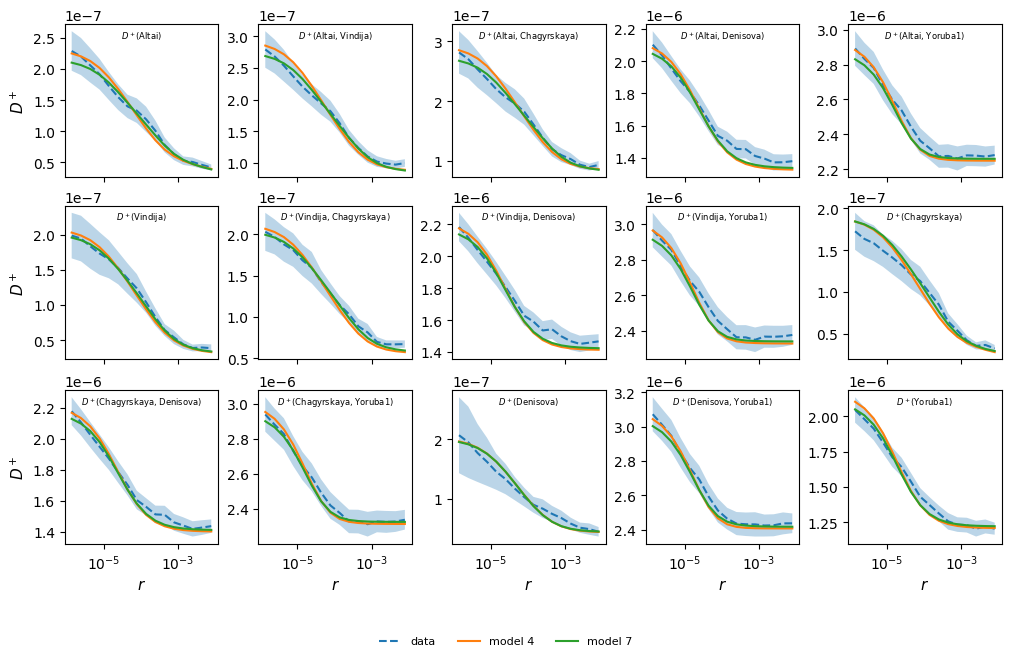

In [18]:
graph_fname_7 = "fitted_models/model_7_Bherer_fit_5.yaml"
graph_fname_4 = "fitted_models/model_4_Bherer_fit_27.yaml"
data_fname = "../../data/stats_Bherer_weighted.pkl"
data = dpluspy.inference.load_stats(data_fname, graph=graph_fname_7, return_dict=1)
model_4 = dpluspy.inference.compute_bin_stats(graph_fname_4, sampled_demes=data["pop_ids"],
    bins=data["bins"], u=1.3e-8)
model_7 = dpluspy.inference.compute_bin_stats(graph_fname_7, sampled_demes=data["pop_ids"],
    bins=data["bins"], u=1.3e-8)
dpluspy.plotting.plot_D_plus_curves(
    models=[model_4, model_7],
    means=data["means"],
    varcovs=data["varcovs"],
    bins=data["bins"],
    pop_ids=data["pop_ids"],
    labels=["data", "model 4", "model 7"]
)